# Continuous Action Space A2C Tracking Agent

Continuous control reinforcement learning targets continuous domains by parameterizing action distributions (like Gaussian mean $\mu$ and standard deviation $\sigma$ coordinates) instead of discrete classes. This notebook implements a continuous Advantage Actor-Critic (A2C) agent in PyTorch trained to track and hold a zero coordinate target in a 1D physics environment.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import numpy as np
import matplotlib.pyplot as plt

# Custom 1D Position Tracking Environment Simulator
# State variables: [position, velocity]
class PositionTrackerEnv:
    def __init__(self):
        self.reset()
        
    def reset(self):
        self.pos = np.random.uniform(-1.5, 1.5)
        self.vel = 0.0
        self.steps = 0
        return np.array([self.pos, self.vel], dtype=np.float32)
        
    def step(self, action):
        self.steps += 1
        # Action represents thrust acceleration force applied
        thrust = np.clip(action, -2.0, 2.0)
        
        # Physics updates
        dt = 0.05
        self.vel += dt * (thrust - 0.1 * self.vel) # Acceleration with friction damping
        self.pos += dt * self.vel
        
        # Reward is negative distance from zero coordinate target
        reward = -abs(self.pos)
        
        done = False
        if abs(self.pos) > 3.0 or self.steps >= 120:
            done = True
            
        return np.array([self.pos, self.vel], dtype=np.float32), reward, done

env = PositionTrackerEnv()



## Continuous Actor-Critic Network

We implement the continuous Actor-Critic network in PyTorch:
1. **Actor Head**: Outputs Gaussian distribution parameters: Mean ($\mu$) and standard deviation ($\sigma$).
2. **Critic Head**: Outputs a scalar value estimating state values ($V(s)$).



In [2]:
class ContinuousActorCritic(nn.Module):
    def __init__(self, state_dim=2):
        super(ContinuousActorCritic, self).__init__()
        
        self.shared = nn.Sequential(
            nn.Linear(state_dim, 32),
            nn.ReLU()
        )
        
        self.mu = nn.Linear(32, 1)
        self.log_std = nn.Linear(32, 1) # Output log std to ensure positivity via exp
        self.critic = nn.Linear(32, 1)
        
    def forward(self, x):
        h = self.shared(x)
        mu = torch.tanh(self.mu(h)) * 2.0 # Scale action range to [-2, 2]
        std = torch.exp(torch.clamp(self.log_std(h), -2.0, 1.0)) # Clamp std boundaries
        value = self.critic(h)
        return mu, std, value

model = ContinuousActorCritic(state_dim=2)
optimizer = optim.Adam(model.parameters(), lr=0.005)



## Continuous A2C Agent Training

We train our agent for 200 episodes. After each step, we calculate Temporal Difference (TD) target, compute Critic value loss, sample continuous action values from Normal distributions, and update networks.



In [3]:
n_episodes = 200
gamma = 0.98
episode_rewards = []

print("Training Continuous Actor-Critic (A2C) agent...")
for ep in range(1, n_episodes + 1):
    state = env.reset()
    done = False
    total_reward = 0
    
    while not done:
        state_t = torch.FloatTensor(state)
        mu, std, value = model(state_t)
        
        # Sample continuous action from Normal distribution
        dist = Normal(mu, std)
        action = dist.sample()
        
        next_state, reward, done = env.step(action.item())
        total_reward += reward
        
        next_state_t = torch.FloatTensor(next_state)
        _, _, next_value = model(next_state_t)
        
        # Compute Advantage & TD Target
        td_target = reward + (0.0 if done else gamma * next_value.item())
        advantage = td_target - value.item()
        
        # Critic MSE loss
        critic_loss = (value - td_target).pow(2)
        
        # Actor log probability advantage loss
        actor_loss = -dist.log_prob(action) * advantage
        
        # Joint gradient step update
        loss = actor_loss + 0.5 * critic_loss
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        state = next_state
        
    episode_rewards.append(total_reward)
    
    if ep % 40 == 0:
        avg_reward = np.mean(episode_rewards[-40:])
        print(f"Episode {ep:3d}/{n_episodes} | Average Reward (last 40): {avg_reward:.2f}")



Training Continuous Actor-Critic (A2C) agent...
Episode  40/200 | Average Reward (last 40): -69.17
Episode  80/200 | Average Reward (last 40): -30.20
Episode 120/200 | Average Reward (last 40): -23.38
Episode 160/200 | Average Reward (last 40): -21.88
Episode 200/200 | Average Reward (last 40): -27.38


## Reward Convergence Curve

We plot the continuous control cumulative rewards accumulated by the A2C agent across episodes using Matplotlib.



<cell>:13: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



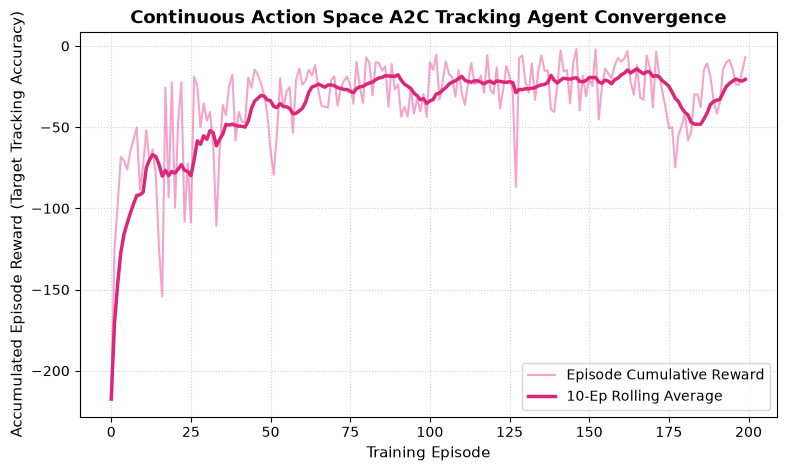

In [4]:
plt.figure(figsize=(9, 5))
plt.plot(episode_rewards, label='Episode Cumulative Reward', color='#EC4899', alpha=0.5)

# Rolling average overlay
rolling_rewards = [np.mean(episode_rewards[max(0, i-10):i+1]) for i in range(len(episode_rewards))]
plt.plot(rolling_rewards, label='10-Ep Rolling Average', color='#DB2777', linewidth=2.5)

plt.title('Continuous Action Space A2C Tracking Agent Convergence', fontsize=13, fontweight='bold')
plt.xlabel('Training Episode', fontsize=11)
plt.ylabel('Accumulated Episode Reward (Target Tracking Accuracy)', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
